# 第064讲 最大间隔与软间隔

先计算几何，再运行原始优化与线性SVC。全部输出来自真实CPU执行。

In [1]:
from pathlib import Path
import json, numpy as np
from IPython.display import display, Image
from margin import geometry, objective, solve_primal
from experiment import run
from plots import build
from common import write_json
print('第064讲；个人输出写入 outputs/notebook')

第064讲；个人输出写入 outputs/notebook


## 四点手算与尺度变化

In [2]:
X=np.array([[-1,-1],[-1,1],[1,-1],[1,1]],float)
y=np.array([-1,-1,1,1])
for w in ([1,0],[3,0]):
    print(w, geometry(X,y,w,0))
print('手算目标',objective(X,y,[1,0],0,1))

[1, 0] {'functional_margin': [1.0, 1.0, 1.0, 1.0], 'signed_distance': [1.0, 1.0, 1.0, 1.0], 'slack': [0.0, 0.0, 0.0, 0.0], 'norm_w': 1.0, 'canonical_half_width': 1.0, 'canonical_full_width': 2.0, 'misclassified': 0, 'within_margin': 0}
[3, 0] {'functional_margin': [3.0, 3.0, 3.0, 3.0], 'signed_distance': [1.0, 1.0, 1.0, 1.0], 'slack': [0.0, 0.0, 0.0, 0.0], 'norm_w': 3.0, 'canonical_half_width': 0.3333333333333333, 'canonical_full_width': 0.6666666666666666, 'misclassified': 0, 'within_margin': 0}
手算目标 0.5


## 从头训练和原始约束求解

In [3]:
result=run()
write_json('outputs/notebook/result.json',result)
print('selected C',result['candidates'][result['selected_index']]['C'])
print('primal versus SVC',result['primal_vs_svc'])
print('sealed test accuracy',result['test']['accuracy'])

selected C 0.03
primal versus SVC {'objective_difference': 1.6667711655315998e-10, 'max_score_difference': 1.087871481786351e-08}
sealed test accuracy 0.95


In [4]:
for row in result['candidates']:
    print(row['C'],'validation',row['validation_accuracy'],'width',row['canonical_full_width'],'hinge',sum(row['slack']))
print('scaling probe',result['scaling_probe'])

0.03 validation 0.9375 width 2.6239234935573212 hinge 23.950264644253863
0.3 validation 0.925 width 1.4894793283433228 hinge 16.131414034620036
3.0 validation 0.925 width 1.405371830173504 hinge 15.870738248371568
30.0 validation 0.9375 width 1.014409479482569 hinge 15.818477568946445
scaling probe {'unit_multiplier': [1.0, 100.0], 'raw_units_w': [0.7520055790272411, -0.29141172332434184], 'raw_units_b': 0.09054210313260336, 'standardized_original_w': [0.6913213574601864, -0.1389629369283894], 'standardized_original_b': 0.034733920650072844, 'train_mean_changed_units': [-0.004574661279687513, 23.038953990937518], 'train_scale_changed_units': [1.167791306093423, 96.17105239620133], 'validation_accuracy_raw_units': 0.9125, 'validation_accuracy_standardized': 0.9375}


## 六幅可重建图

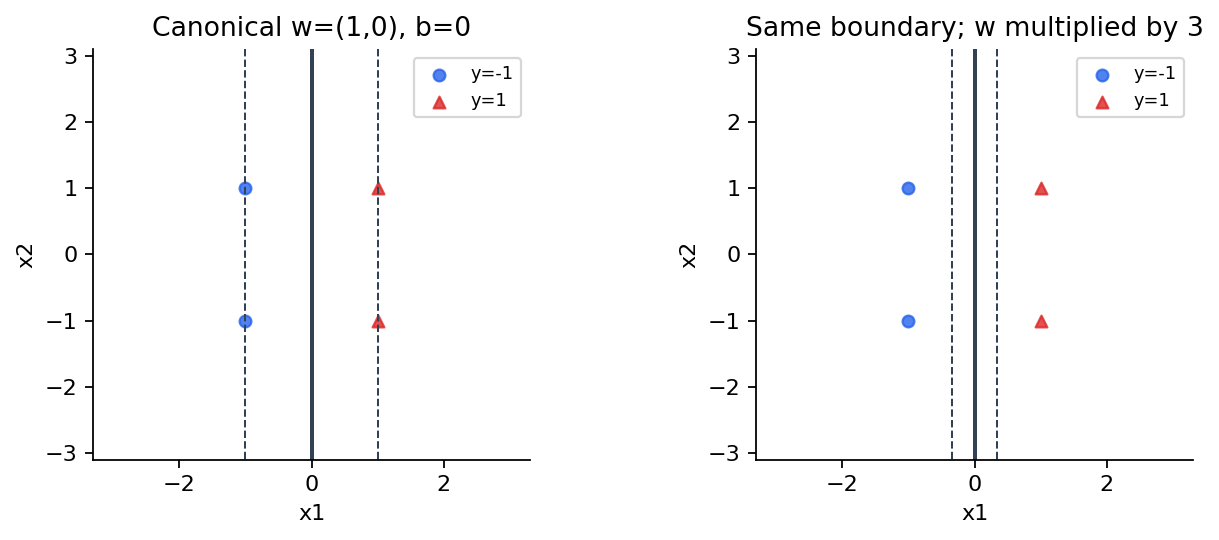

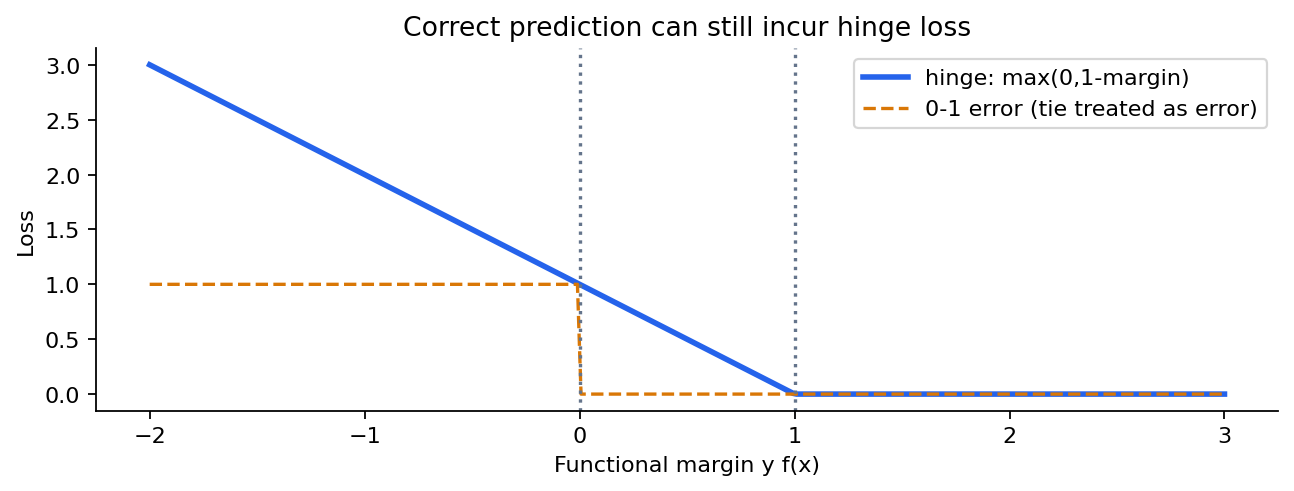

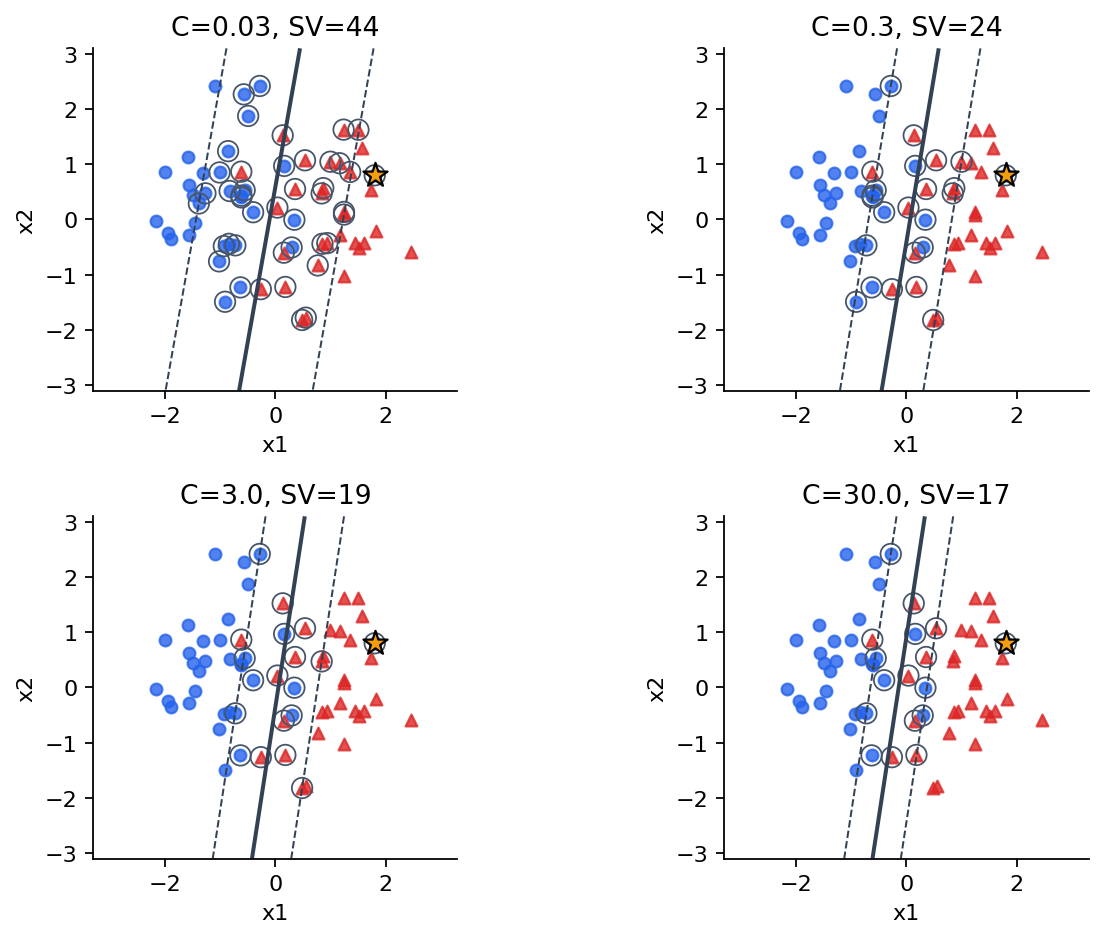

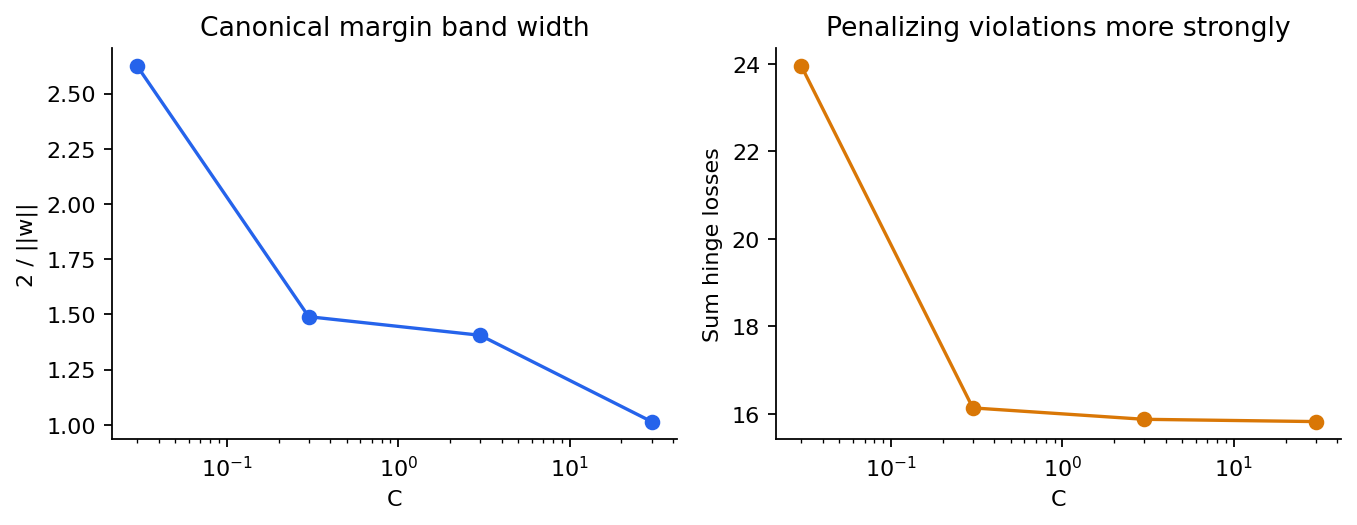

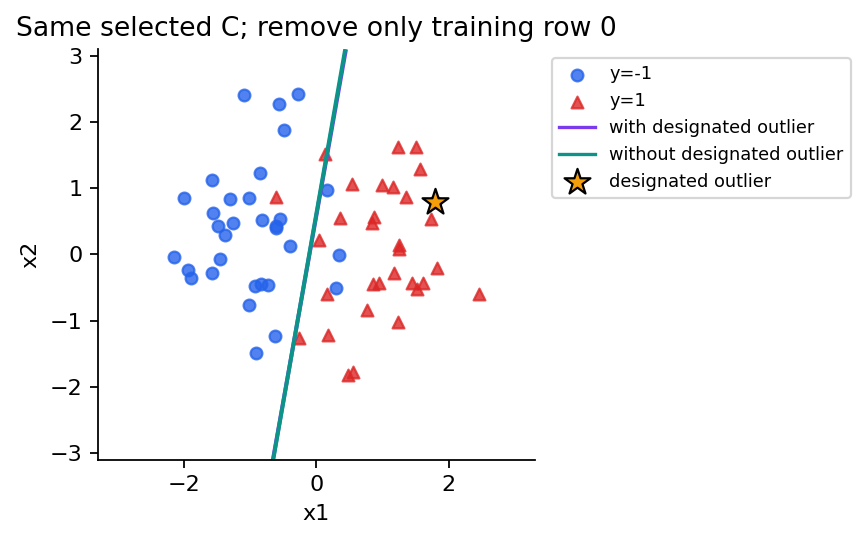

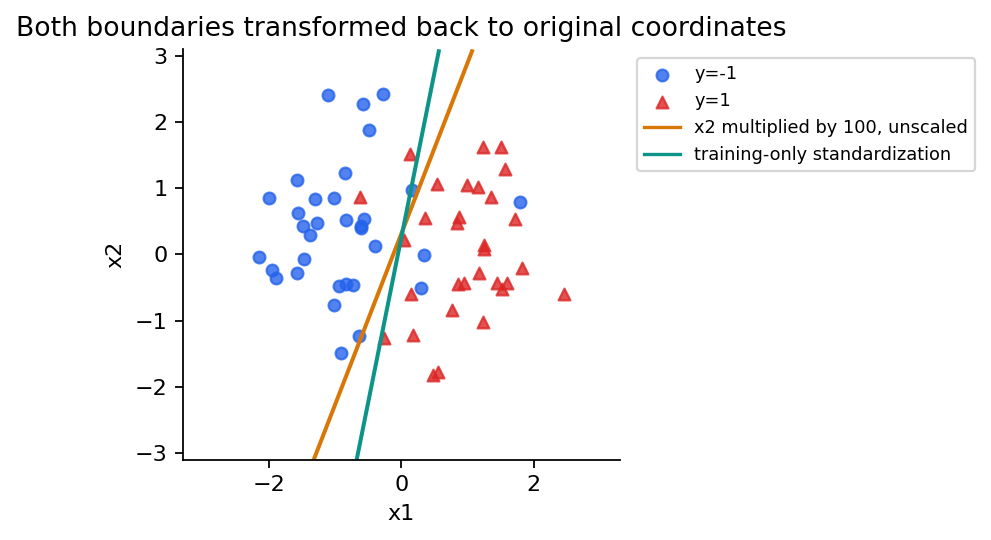

In [5]:
for name in build(result,'outputs/notebook/figures'):
    display(Image(filename=str(Path('outputs/notebook/figures')/name)))

## 再跑完整显式测试

In [6]:
from test_experiment import test
checks=test(result)
print({k:v for k,v in checks.items() if k!='check_names'})

{'status': 'passed', 'checks': 342, 'optimized': False, 'fresh_experiment_replayed': True}


## 练习
解释为什么正确分类仍可能有hinge损失；把标准化后的边界转换回原坐标；说明为何间隔不是概率。详解在answers.pdf。